# S8_Freezing_Temp_Comp.ipynb
This notebook compares freezing temperature oscillation across JDSSS and studies performed S1 wetness detection studies including Marin et al. (2020), Lund et al. (2023), and Manickam et al. (2020)

For additional details see ../preprocess/grand_mesa/domains.ipynb  

In [1]:
import matplotlib.pyplot as plt 
import geopandas as gpd 
import xarray as xr
import contextily as ctx
from shapely.geometry import box

## Air Temperature

### CUES

In [2]:
cues_ds = xr.load_dataset('../../data/cues/cues/cues_2015_2025.nc')
cues_ds

<xarray.Dataset> Size: 2GB
Dimensions:                                         (datetime: 5520960)
Coordinates:
  * datetime                                        (datetime) datetime64[ns] 44MB ...
Data variables: (12/59)
    air_temperature                                 (datetime) float32 22MB -...
    air_temperature_data_flag                       (datetime) int32 22MB 0 ....
    relative_humidity                               (datetime) float32 22MB 1...
    relative_humidity_data_flag                     (datetime) int32 22MB 0 ....
    station_pressure                                (datetime) float32 22MB 7...
    station_pressure_data_flag                      (datetime) int32 22MB 0 ....
    ...                                              ...
    accumulated_rain_1min                           (datetime) float32 22MB n...
    precipitation_type                              (datetime) <U26 574MB '' ...
    precipitation_phase                             (datetime) int32 22MB 0 ....
    number_of_hydrometeors                          (datetime) float32 22MB n...
    equivalent_radar_reflectivity                   (datetime) float32 22MB n...
    visibility                                      (datetime) float32 22MB n...
Attributes: (12/15)
    station_name:       Jeff Dozier Snow Study Site
    station_info:       Formerly the CRREL UCSB Energy Site (CUES), https://s...
    station_location:   Mammoth Mountain, CA, USA
    station_latitude:   37.6431
    station_longitude:  -119.0291
    station_elevation:  2936 m
    ...                 ...
    time_zone_offset:   UTC-8
    created_by:         Manda Chasteen, Leidos
    contact_info:       manda.chasteen@leidos.com, edward.h.bair@leidos.com
    created_date:       2025-08-09
    last_modified:      2025-09-08
    data_interval:      1 min

### Grand Mesa

In [3]:
import pandas as pd
gm_obs_df = pd.read_csv("../../data/grand_mesa/SNEX_Met_GMSP2_final_output.csv")
gm_obs_df['TIMESTAMP'] = pd.to_datetime(gm_obs_df['TIMESTAMP'])
gm_ds = gm_obs_df.rename(columns = {'TIMESTAMP':'time'}).set_index('time').to_xarray()
gm_ds

<xarray.Dataset> Size: 7MB
Dimensions:               (time: 41350)
Coordinates:
  * time                  (time) datetime64[ns] 331kB 2017-06-21T22:00:00 ......
Data variables: (12/21)
    RH_10ft               (time) float64 331kB 23.59 22.88 24.22 ... 85.47 85.23
    RH_20ft               (time) float64 331kB 23.09 22.55 23.67 ... 84.68 84.23
    BP_kPa_Avg            (time) float64 331kB 69.46 69.43 69.4 ... 67.63 67.63
    AirTC_20ft_Avg        (time) float64 331kB 19.89 20.01 ... -12.55 -12.64
    AirTC_10ft_Avg        (time) float64 331kB 20.16 20.36 ... -12.72 -12.85
    WSms_20ft_Avg         (time) float64 331kB 1.26 1.068 1.093 ... 0.672 0.69
    ...                    ...
    SM_50cm_Avg           (time) float64 331kB 0.405 0.405 0.405 ... 0.365 0.365
    TC_5cm_Avg            (time) float64 331kB 24.2 24.34 24.45 ... 0.212 0.202
    TC_20cm_Avg           (time) float64 331kB 14.95 15.29 15.81 ... 0.595 0.598
    TC_50cm_Avg           (time) float64 331kB 9.9 9.9 9.9 9.9 ... 1.1 1.1 1.1
    DistanceSensToGnd(m)  (time) float64 331kB -9.999e+03 -9.999e+03 ... 2.099
    SnowDepthFilter(m)    (time) float64 331kB -9.999e+03 -9.999e+03 ... 2.099

### Weissfluhjoch

In [4]:
weiss_ds = xr.load_dataset('/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/data/weissfluhjoch/wfj_smet.nc')
weiss_ds

<xarray.Dataset> Size: 50MB
Dimensions:  (time: 365664)
Coordinates:
  * time     (time) datetime64[ns] 3MB 1996-09-01T01:00:00 ... 2017-07-11T00:...
Data variables: (12/16)
    TA       (time) float64 3MB 273.1 273.1 273.1 273.1 ... 279.1 278.9 278.9
    RH       (time) float64 3MB 0.977 0.973 0.959 0.938 ... 0.995 0.99 0.973
    VW       (time) float64 3MB 1.46 1.98 2.35 2.6 2.76 ... 0.5 3.2 2.2 2.4 1.1
    DW       (time) float64 3MB 301.1 316.6 329.3 300.7 ... 320.0 345.0 311.0
    ISWR     (time) float64 3MB 0.0 0.0 0.0 0.0 ... -1.367 -0.28 -0.26 -0.3133
    OSWR     (time) float64 3MB 0.0 0.0 0.0 0.0 ... -2.9 -1.207 -0.8733 -0.56
    ...       ...
    HS       (time) float64 3MB nan nan nan nan nan nan ... 1.0 1.0 1.0 0.0 1.0
    TSG      (time) float64 3MB nan nan nan nan nan ... 280.4 280.1 279.8 279.6
    TSS      (time) float64 3MB nan nan nan nan nan ... 280.6 280.4 280.1 280.1
    LYSI     (time) float64 3MB 0.2 0.0 0.0 0.0 0.0 ... 0.0 1.28 4.16 1.28 1.44
    SWE_M    (time) float64 3MB nan nan nan nan nan nan ... nan nan nan nan nan
    TA_C     (time) float64 3MB -0.1 -0.1 0.0 0.0 -0.4 ... 7.7 6.4 6.0 5.7 5.7
Attributes:
    station_id:  WFJ2
    latitude:    46.82962
    longitude:   9.80934
    altitude_m:  2540.0
    source:      wfj_optimaldataset_v7.smet
    tz:          +01

### Addiitonal data download

In [5]:
from pathlib import Path
from urllib.request import Request, urlopen
import json
import time

study_start = pd.Timestamp("2016-10-01", tz="UTC")
study_end = pd.Timestamp("2018-10-01", tz="UTC")
chunk_days = 5
request_pause_seconds = 0.2

south_tyrol_sites = {
    "tumulo": {
        "station_code": "20050SF",
        "site_name": "Alpe del Tumulo",
        "api_name": "Alpe del Tumulo",
    },
    "clozner_loch": {
        "station_code": "90000SF",
        "site_name": "Clozner Loch",
        "api_name": "Lauregno Clozner Loch",
    },
    "fadner": {
        "station_code": "53200SF",
        "site_name": "Malga Fadner",
        "api_name": "Rio Bianco Malga Fadner",
    },
}

output_dir = Path("../../../data/marin_2020_air_temperature")
output_dir.mkdir(parents=True, exist_ok=True)

base_url = "https://mobility.api.opendatahub.com/v2/flat,node/MeteoStation/air-temperature"
headers = {"User-Agent": "Mozilla/5.0"}


def fetch_air_temperature_chunks(station_code, start, end, chunk_days=5, pause_seconds=0.2):
    chunk_start = start
    records = []

    while chunk_start < end:
        chunk_end = min(chunk_start + pd.Timedelta(days=chunk_days), end)
        url = (
            f"{base_url}/{chunk_start.strftime('%Y-%m-%d')}/{chunk_end.strftime('%Y-%m-%d')}"
            f"?where=scode.eq.{station_code}&limit=-1"
        )
        request = Request(url, headers=headers)
        with urlopen(request) as response:
            payload = json.load(response)
        records.extend(payload.get("data", []))
        chunk_start = chunk_end
        time.sleep(pause_seconds)

    return records


def records_to_dataframe(records, site_key, station_code, site_name, api_name):
    df = pd.DataFrame(records)
    if df.empty:
        return pd.DataFrame(
            columns=["datetime", "air_temperature", "station_code", "site_key", "site_name", "api_name"]
        )

    df = df[["mvalidtime", "mvalue"]].copy()
    df["datetime"] = pd.to_datetime(df["mvalidtime"], utc=True)
    df["air_temperature"] = pd.to_numeric(df["mvalue"], errors="coerce")
    df["station_code"] = station_code
    df["site_key"] = site_key
    df["site_name"] = site_name
    df["api_name"] = api_name
    df = df[["datetime", "air_temperature", "station_code", "site_key", "site_name", "api_name"]]
    df = df.drop_duplicates(subset="datetime").sort_values("datetime").reset_index(drop=True)
    return df


site_air_temperature = {}
site_datasets = {}
download_summary = []

for site_key, site_info in south_tyrol_sites.items():
    records = fetch_air_temperature_chunks(
        station_code=site_info["station_code"],
        start=study_start,
        end=study_end,
        chunk_days=chunk_days,
        pause_seconds=request_pause_seconds,
    )

    site_df = records_to_dataframe(
        records=records,
        site_key=site_key,
        station_code=site_info["station_code"],
        site_name=site_info["site_name"],
        api_name=site_info["api_name"],
    )

    csv_path = output_dir / f"{site_key}_air_temperature_2016_2018.csv"
    site_df.to_csv(csv_path, index=False)

    site_air_temperature[site_key] = site_df
    site_datasets[site_key] = site_df.set_index("datetime")[["air_temperature"]].to_xarray()

    download_summary.append(
        {
            "site_key": site_key,
            "site_name": site_info["site_name"],
            "api_name": site_info["api_name"],
            "station_code": site_info["station_code"],
            "n_records": len(site_df),
            "start": site_df["datetime"].min(),
            "end": site_df["datetime"].max(),
            "csv_path": str(csv_path),
        }
    )

tumulo_df = site_air_temperature["tumulo"]
clozner_loch_df = site_air_temperature["clozner_loch"]
fadner_df = site_air_temperature["fadner"]

tumulo_ds = site_datasets["tumulo"]
clozner_loch_ds = site_datasets["clozner_loch"]
fadner_ds = site_datasets["fadner"]

south_tyrol_download_summary = pd.DataFrame(download_summary)
south_tyrol_download_summary

,site_key,site_name,api_name,station_code,n_records,start,end,csv_path
0,tumulo,Alpe del Tumulo,Alpe del Tumulo,20050SF,100546,2016-10-01 00:00:00+00:00,2018-09-30 23:50:00+00:00,../../../data/marin_2020_air_temperature/tumul...
1,clozner_loch,Clozner Loch,Lauregno Clozner Loch,90000SF,100486,2016-10-01 00:00:00+00:00,2018-09-30 23:50:00+00:00,../../../data/marin_2020_air_temperature/clozn...
2,fadner,Malga Fadner,Rio Bianco Malga Fadner,53200SF,94136,2016-11-19 13:10:00+00:00,2018-09-30 23:50:00+00:00,../../../data/marin_2020_air_temperature/fadne...


## South Tyrol Air Temperature Data Sources

The Alpe del Tumulo, Clozner Loch, and Malga Fadner air-temperature datasets were downloaded from the South Tyrol Open Data Hub meteorological API:

- Base endpoint: https://mobility.api.opendatahub.com/v2/flat,node/MeteoStation/air-temperature
- Query pattern used in this notebook: {start_date}/{end_date}?where=scode.eq.{station_code}&limit=-1
- Variable requested: air temperature (mvalue), parsed to the air_temperature column
- Time range requested: 2016-10-01 to 2018-10-01 (UTC)
- Requests were chunked in 5-day windows and concatenated

Station mappings used:

- Alpe del Tumulo: station code 20050SF (api_name: Alpe del Tumulo)
- Clozner Loch: station code 90000SF (api_name: Lauregno Clozner Loch)
- Malga Fadner: station code 53200SF (api_name: Rio Bianco Malga Fadner)

Downloaded outputs were written to:

- ../../../data/marin_2020_air_temperature/tumulo_air_temperature_2016_2018.csv
- ../../../data/marin_2020_air_temperature/clozner_loch_air_temperature_2016_2018.csv
- ../../../data/marin_2020_air_temperature/fadner_air_temperature_2016_2018.csv

These CSVs are then loaded into tumulo_df, clozner_loch_df, and fadner_df for downstream analysis and plotting.


## Weissfluhjoch 
Wever, N. (2017). WFJ_MOD: Meteorological and snowpack measurements from Weissfluhjoch, Davos, Switzerland. EnviDat. https://www.doi.org/10.16904/1.

## JDSSS 
Chasteen, M. (2025). Meteorological and snowpack observations from the Jeff Dozier Snow Study Site [formerly the CRREL/UCSB Energy Site (CUES)] on Mammoth Mountain, CA, USA: 1 January 2015 – 30 June 2025 [Data set]. Zenodo. https://doi.org/10.5281/zenodo.17179962

# Figures

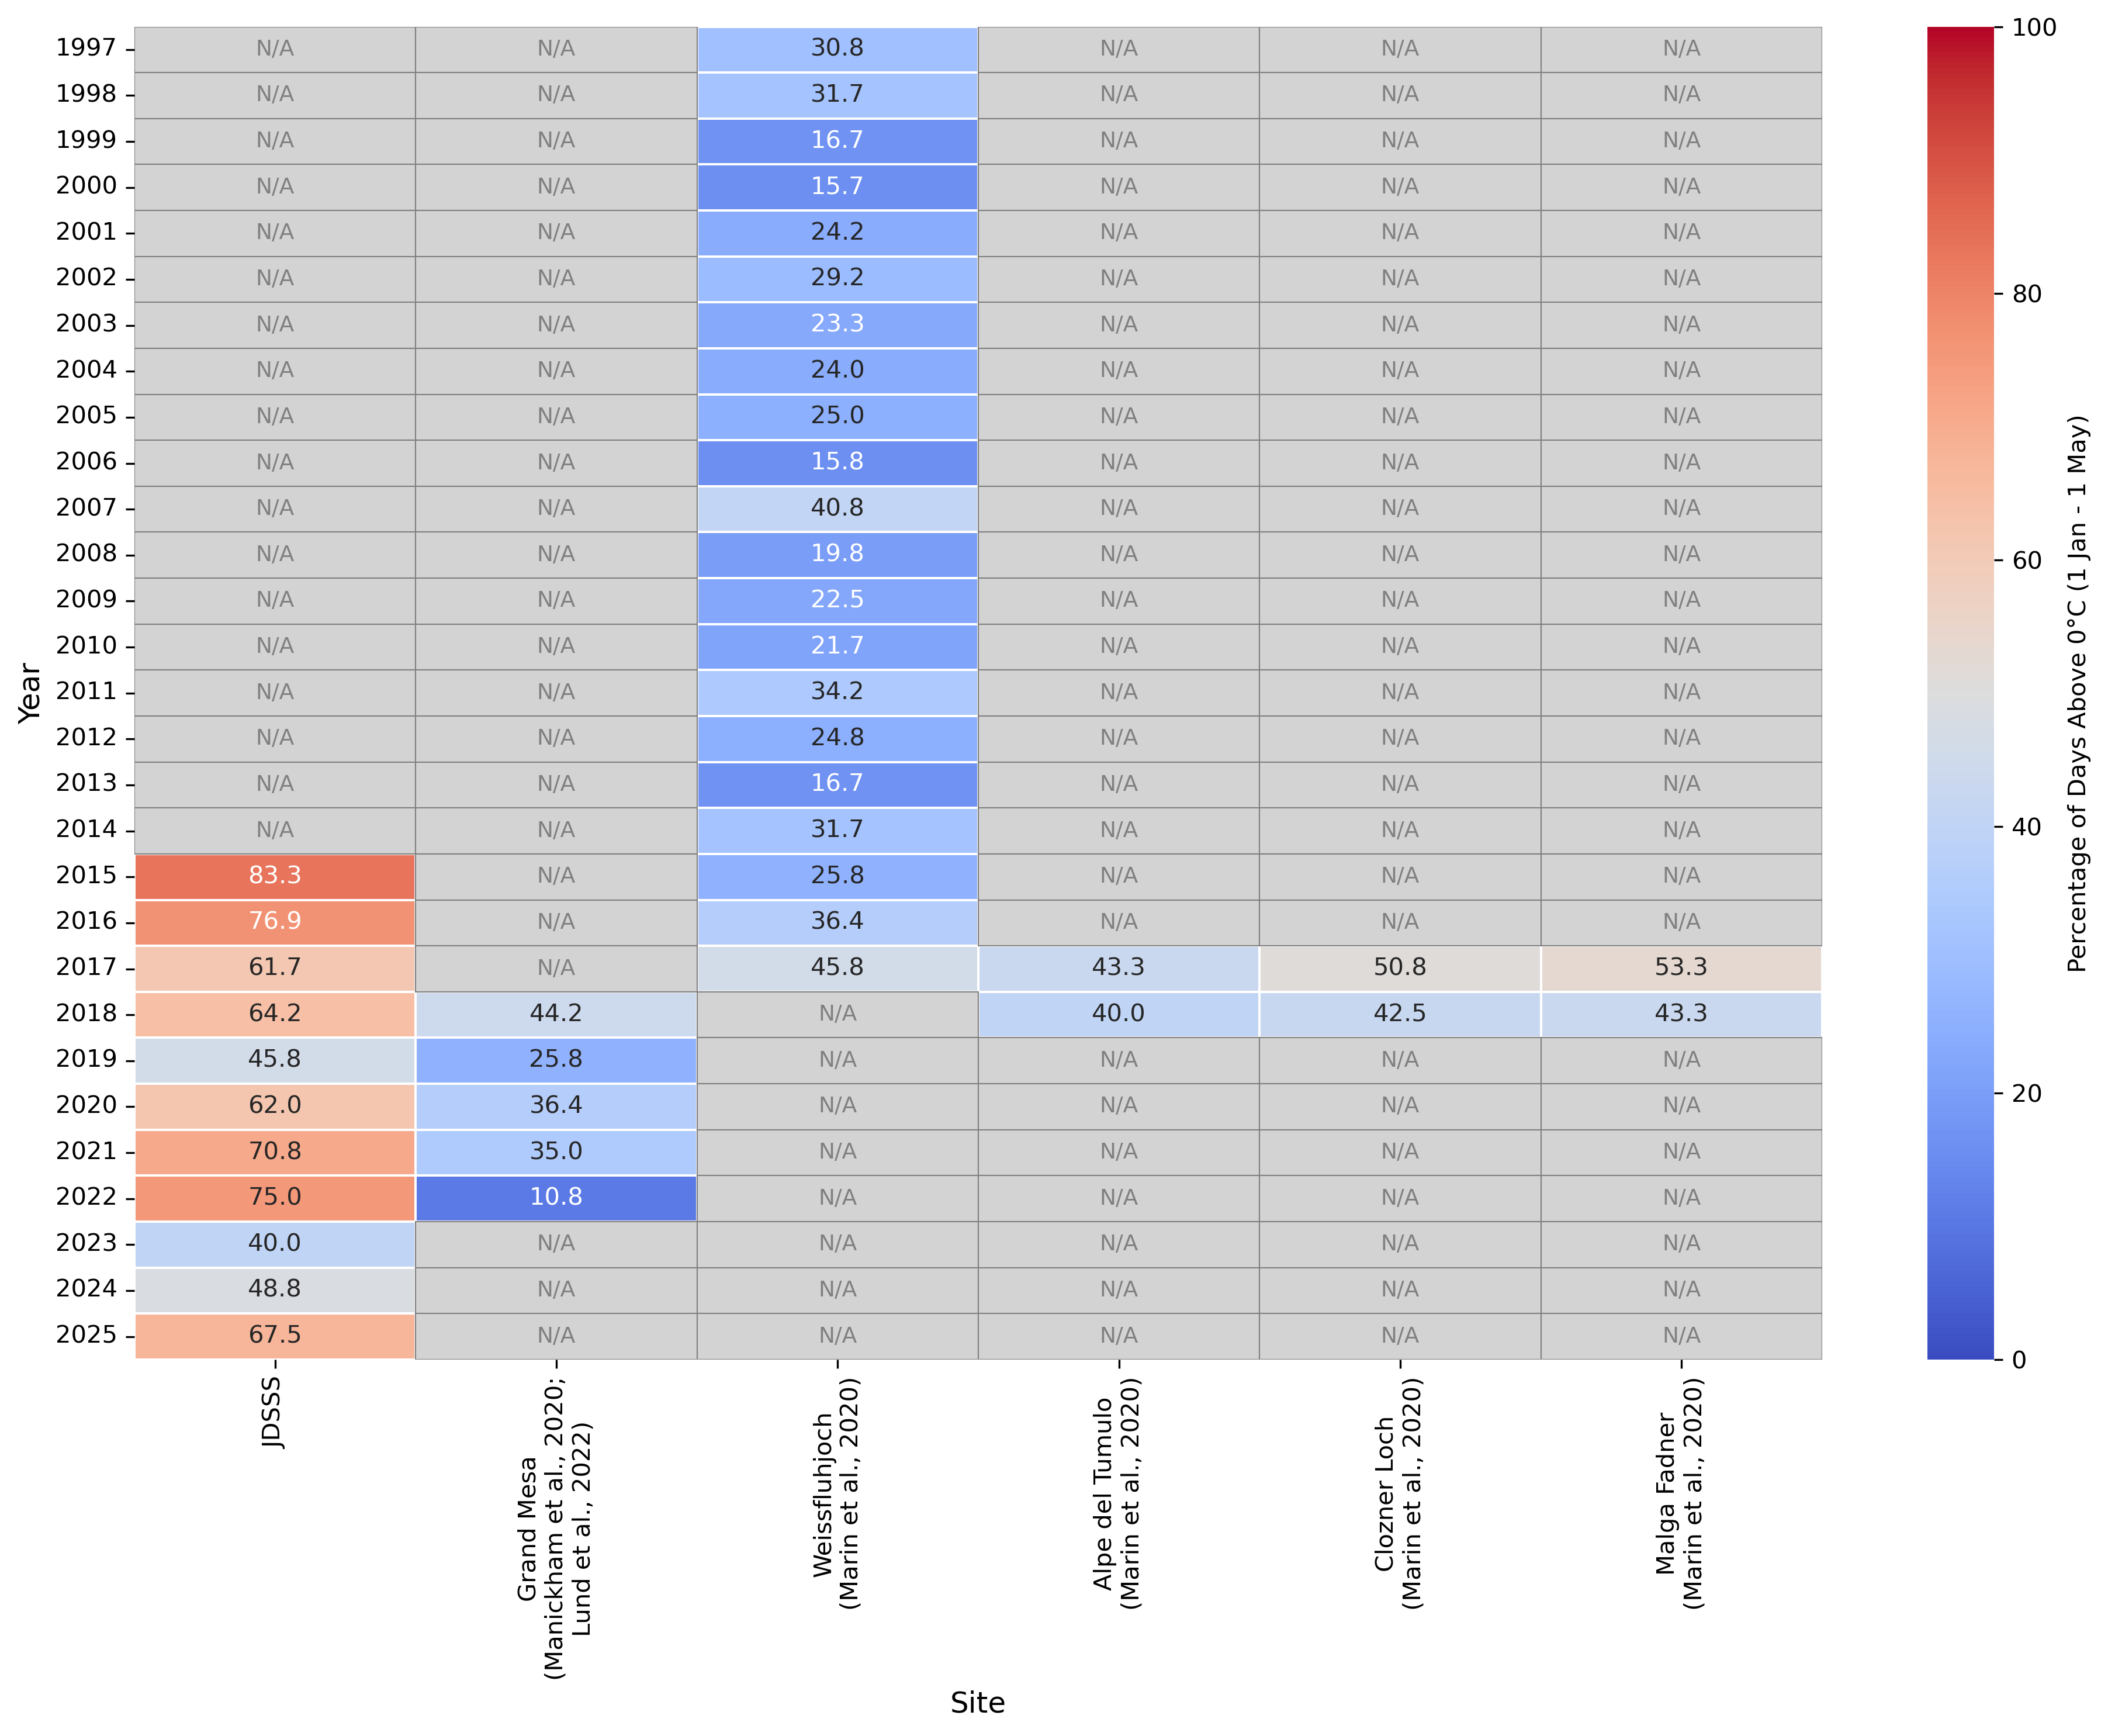

,year,JDSSS,"Grand Mesa\n(Manickham et al., 2020;\nLund et al., 2022)","Weissfluhjoch\n(Marin et al., 2020)","Alpe del Tumulo\n(Marin et al., 2020)","Clozner Loch\n(Marin et al., 2020)","Malga Fadner\n(Marin et al., 2020)"
0,1997,NaN,NaN,30.8,NaN,NaN,NaN
1,1998,NaN,NaN,31.7,NaN,NaN,NaN
2,1999,NaN,NaN,16.7,NaN,NaN,NaN
3,2000,NaN,NaN,15.7,NaN,NaN,NaN
4,2001,NaN,NaN,24.2,NaN,NaN,NaN
5,2002,NaN,NaN,29.2,NaN,NaN,NaN
6,2003,NaN,NaN,23.3,NaN,NaN,NaN
7,2004,NaN,NaN,24.0,NaN,NaN,NaN
8,2005,NaN,NaN,25.0,NaN,NaN,NaN
9,2006,NaN,NaN,15.8,NaN,NaN,NaN


In [7]:
# Heatmap including the newly downloaded Marin et al. South Tyrol stations
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
all_site_hourly = {
    "JDSSS": cues_ds["air_temperature"].to_series().sort_index().resample("1h").mean(),
    "Grand Mesa\n(Manickham et al., 2020;\nLund et al., 2022)": gm_ds["AirTC_10ft_Avg"].to_series().sort_index().resample("1h").mean(),
    "Weissfluhjoch\n(Marin et al., 2020)": weiss_ds["TA_C"].to_series().sort_index().resample("1h").mean(),
    "Alpe del Tumulo\n(Marin et al., 2020)": tumulo_df.set_index("datetime")["air_temperature"].sort_index().resample("1h").mean(),
    "Clozner Loch\n(Marin et al., 2020)": clozner_loch_df.set_index("datetime")["air_temperature"].sort_index().resample("1h").mean(),
    "Malga Fadner\n(Marin et al., 2020)": fadner_df.set_index("datetime")["air_temperature"].sort_index().resample("1h").mean(),
}


def normalize_datetime_index(series):
    idx = series.index
    if getattr(idx, "tz", None) is not None:
        series.index = idx.tz_convert("UTC").tz_localize(None)
    else:
        series.index = pd.to_datetime(idx)
    return series.sort_index()


all_site_hourly = {name: normalize_datetime_index(series.copy()) for name, series in all_site_hourly.items()}

all_years_extended = sorted(
    set().union(*[set(series.index.year.values) for series in all_site_hourly.values()])
)

min_valid_fraction = 0.5
records = []

for yr in all_years_extended[1:]:
    start = pd.Timestamp(f"{yr}-01-01")
    end = pd.Timestamp(f"{yr}-05-01")
    total_days = (end - start).days
    min_hours_required = int(total_days * 24 * min_valid_fraction)

    row = {"year": yr}
    for site_name, series in all_site_hourly.items():
        window = series[(series.index >= start) & (series.index < end)]
        valid_hours = int(window.notna().sum())

        if valid_hours >= min_hours_required:
            days_above_zero = window[window > 0].index.normalize().nunique()
            row[site_name] = round(100 * days_above_zero / total_days, 1)
        else:
            row[site_name] = np.nan

    records.append(row)

stats_df_extended = pd.DataFrame(records).sort_values("year").reset_index(drop=True)
heatmap_data_extended = stats_df_extended.set_index("year")

fig, ax = plt.subplots(figsize=(13, 10),dpi = 300)
sns.heatmap(
    heatmap_data_extended,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    cbar_kws={"label": "Percentage of Days Above 0°C (1 Jan - 1 May)"},
    vmin=0,
    vmax=100,
    ax=ax,
    linewidths=0.5,
    mask=heatmap_data_extended.isna(),
)

for i in range(len(heatmap_data_extended)):
    for j in range(len(heatmap_data_extended.columns)):
        if pd.isna(heatmap_data_extended.iloc[i, j]):
            ax.add_patch(
                mpatches.Rectangle(
                    (j, i),
                    1,
                    1,
                    fill=True,
                    facecolor="lightgray",
                    edgecolor="gray",
                    linewidth=0.5,
                )
            )
            ax.text(j + 0.5, i + 0.5, "N/A", ha="center", va="center", color="gray", fontsize=9)

# ax.set_title(
#     "Percentage of Days with Hourly Temperatures Above 0°C\n(January 1 - May 1, all stations)",
#     fontsize=14,
#     fontweight="bold",
# )
ax.set_xlabel("Site", fontsize=12)
ax.set_ylabel("Year", fontsize=12)

# nan_patch = mpatches.Patch(facecolor="lightgray", edgecolor="gray", label="N/A (Data not available)")
# ax.legend(handles=[nan_patch], loc="upper left", bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

stats_df_extended

In [8]:
# Heatmap including the newly downloaded Marin et al. South Tyrol stations
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
all_site_hourly = {
    "JDSSS": cues_ds["air_temperature"].to_series().sort_index().resample("1h").mean(),
    "Grand Mesa": gm_ds["AirTC_10ft_Avg"].to_series().sort_index().resample("1h").mean(),
    "Weissfluhjoch": weiss_ds["TA_C"].to_series().sort_index().resample("1h").mean(),
    "Alpe del Tumulo": tumulo_df.set_index("datetime")["air_temperature"].sort_index().resample("1h").mean(),
    "Clozner Loch": clozner_loch_df.set_index("datetime")["air_temperature"].sort_index().resample("1h").mean(),
    "Malga Fadner": fadner_df.set_index("datetime")["air_temperature"].sort_index().resample("1h").mean(),
}


def normalize_datetime_index(series):
    idx = series.index
    if getattr(idx, "tz", None) is not None:
        series.index = idx.tz_convert("UTC").tz_localize(None)
    else:
        series.index = pd.to_datetime(idx)
    return series.sort_index()


all_site_hourly = {name: normalize_datetime_index(series.copy()) for name, series in all_site_hourly.items()}

all_years_extended = sorted(
    set().union(*[set(series.index.year.values) for series in all_site_hourly.values()])
)

min_valid_fraction = 0.5
records = []

for yr in all_years_extended[1:]:
    start = pd.Timestamp(f"{yr}-01-01")
    end = pd.Timestamp(f"{yr}-05-01")
    total_days = (end - start).days
    min_hours_required = int(total_days * 24 * min_valid_fraction)

    row = {"year": yr}
    for site_name, series in all_site_hourly.items():
        window = series[(series.index >= start) & (series.index < end)]
        valid_hours = int(window.notna().sum())

        if valid_hours >= min_hours_required:
            days_above_zero = window[window > 0].index.normalize().nunique()
            row[site_name] = round(100 * days_above_zero / total_days, 1)
        else:
            row[site_name] = np.nan

    records.append(row)

stats_df_extended = pd.DataFrame(records).sort_values("year").reset_index(drop=True)
heatmap_data_extended = stats_df_extended.set_index("year")
stats_df_extended

,year,JDSSS,Grand Mesa,Weissfluhjoch,Alpe del Tumulo,Clozner Loch,Malga Fadner
0,1997,NaN,NaN,30.8,NaN,NaN,NaN
1,1998,NaN,NaN,31.7,NaN,NaN,NaN
2,1999,NaN,NaN,16.7,NaN,NaN,NaN
3,2000,NaN,NaN,15.7,NaN,NaN,NaN
4,2001,NaN,NaN,24.2,NaN,NaN,NaN
5,2002,NaN,NaN,29.2,NaN,NaN,NaN
6,2003,NaN,NaN,23.3,NaN,NaN,NaN
7,2004,NaN,NaN,24.0,NaN,NaN,NaN
8,2005,NaN,NaN,25.0,NaN,NaN,NaN
9,2006,NaN,NaN,15.8,NaN,NaN,NaN


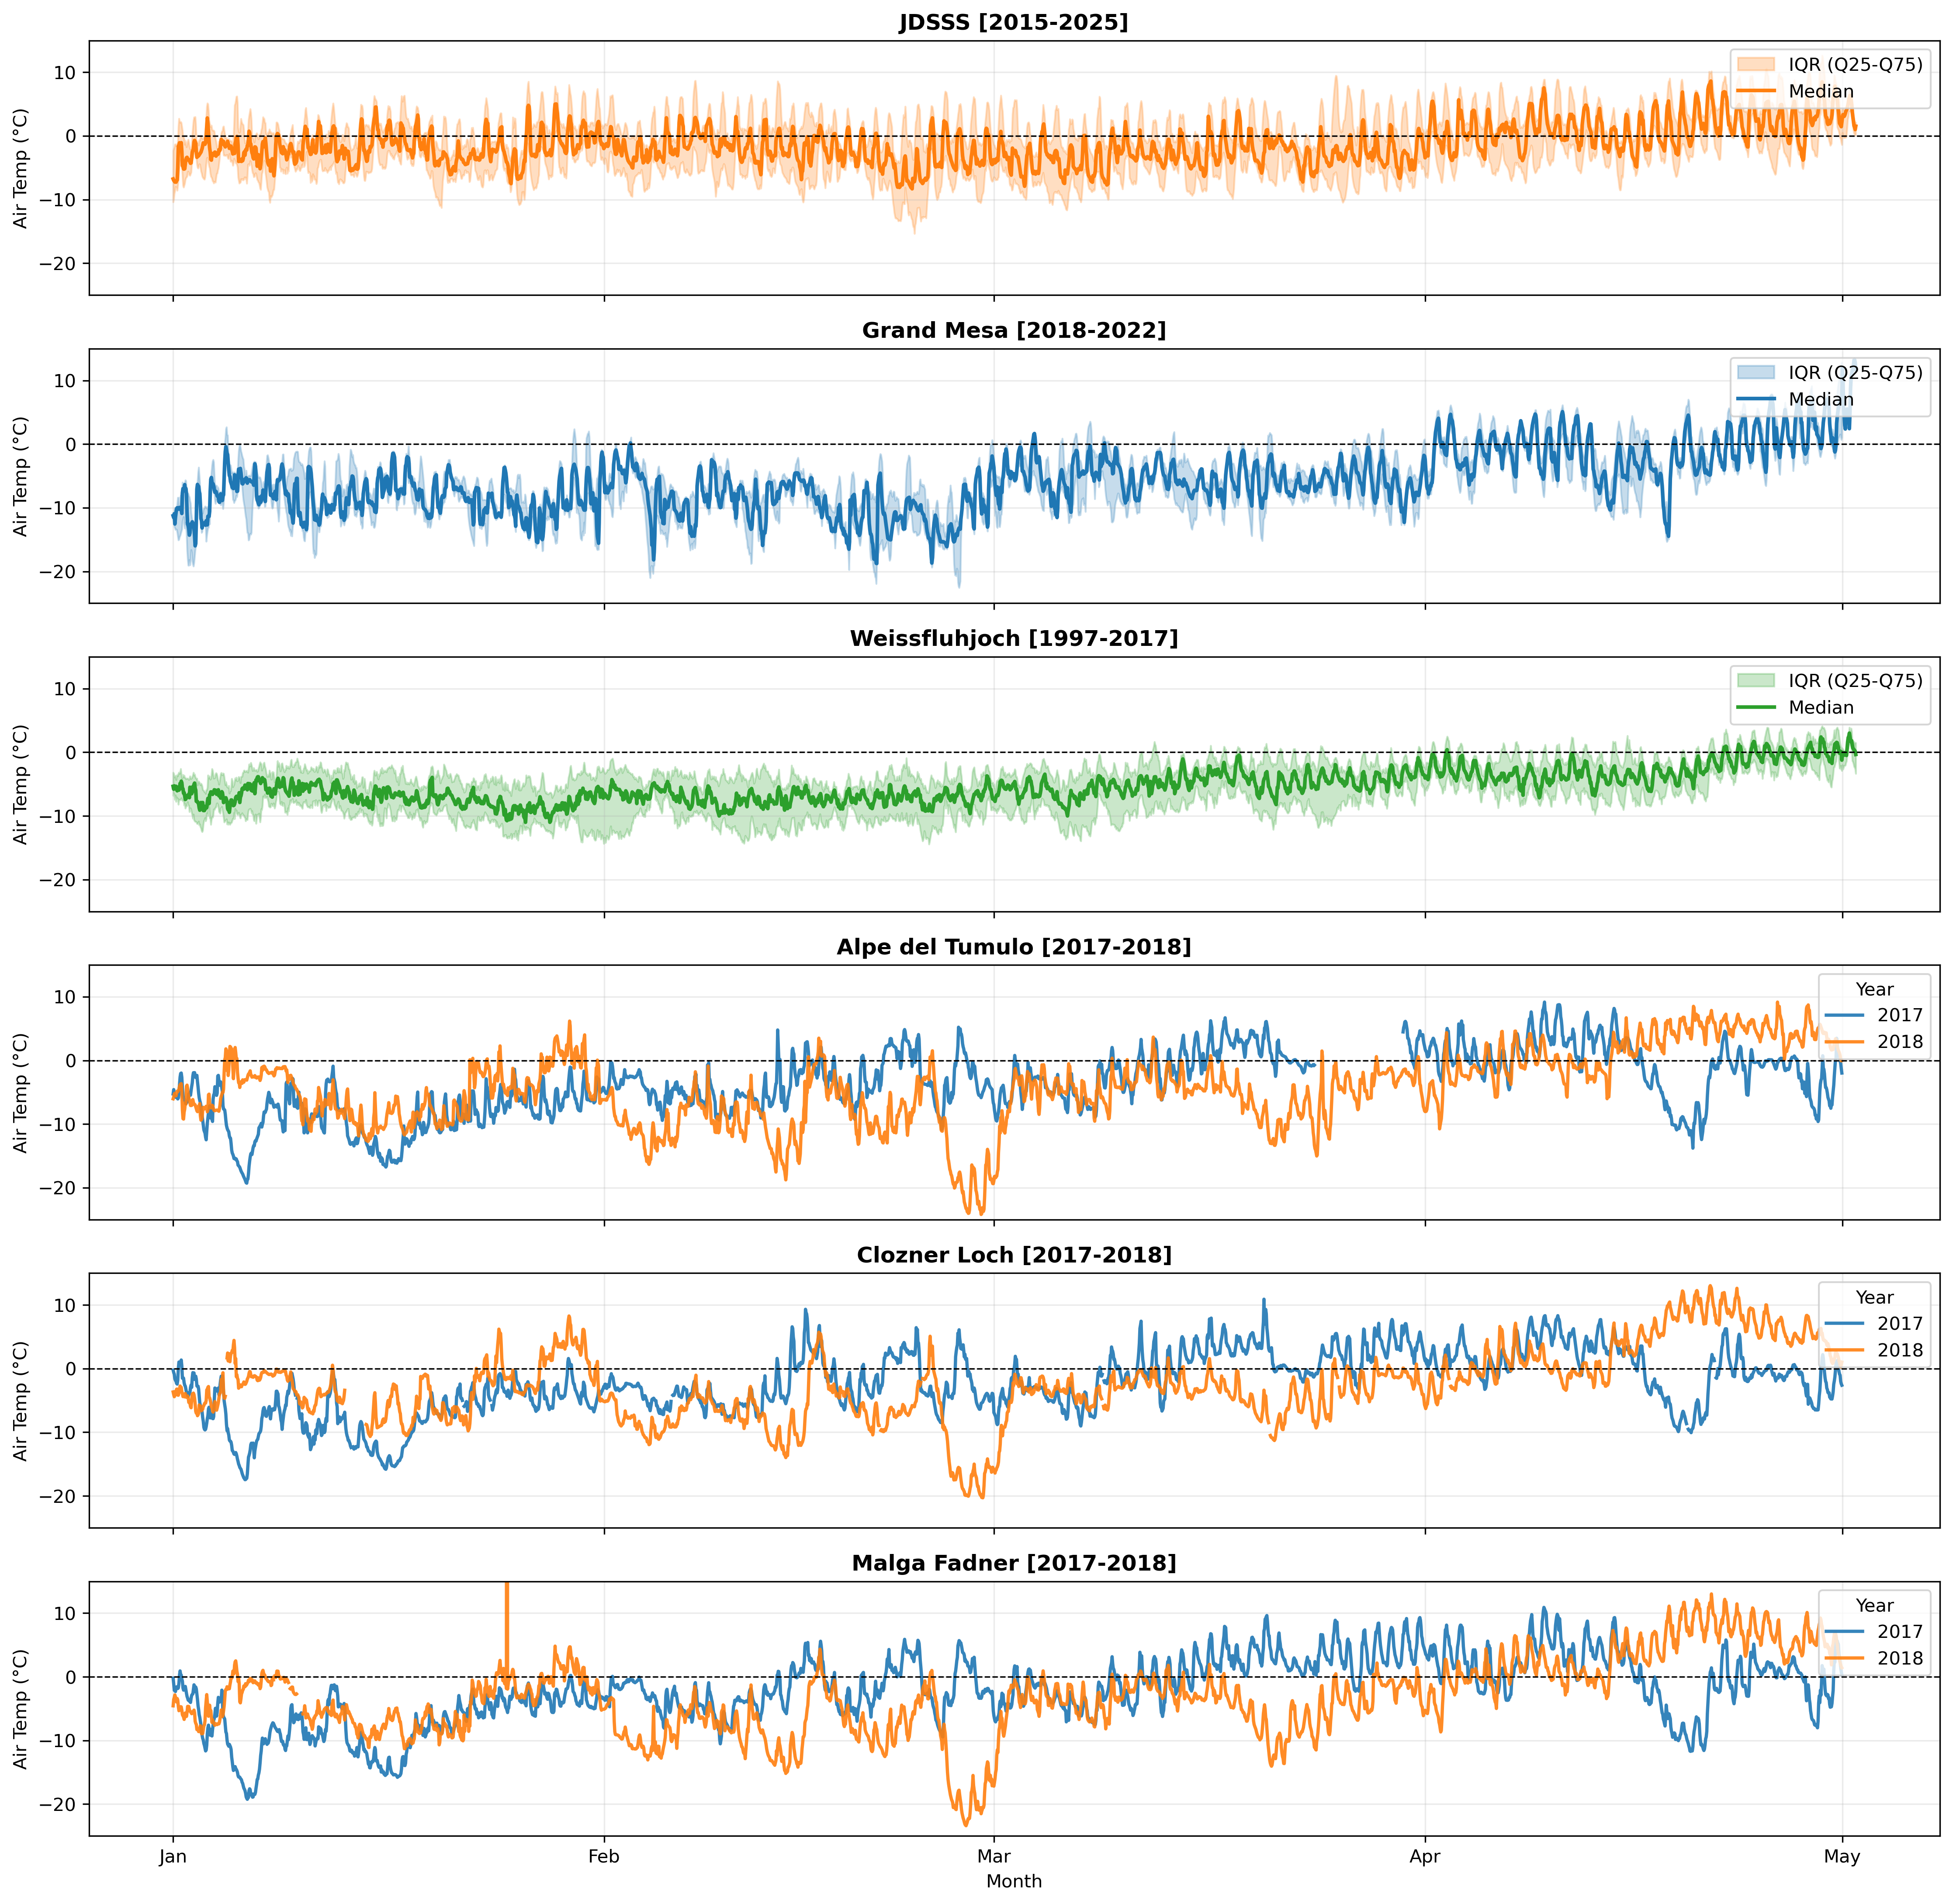

In [11]:
# Jan-May temperature comparison:
# - IQR + median for CUES, Grand Mesa, Weissfluhjoch
# - Individual yearly time series for Alpe del Tumulo, Clozner Loch, Malga Fadner

def normalize_datetime_index_local(series):
    idx = series.index
    if getattr(idx, "tz", None) is not None:
        series.index = idx.tz_convert("UTC").tz_localize(None)
    else:
        series.index = pd.to_datetime(idx)
    return series.sort_index()


def jan_may_hourly_iqr(series):
    s = normalize_datetime_index_local(series.copy())

    # Keep Jan 1 <= time < May 1 for each year.
    in_window = ((s.index.month < 5) | ((s.index.month == 5) & (s.index.day == 1) & (s.index.hour == 0) & (s.index.minute == 0)))
    s = s[in_window]

    # Exclude exactly May 1 00:00 so window is [Jan 1, May 1).
    s = s[~((s.index.month == 5) & (s.index.day == 1) & (s.index.hour == 0) & (s.index.minute == 0))]

    # Hour-of-year index relative to Jan 1 00:00 of each year.
    year_start = pd.to_datetime(s.index.year.astype(str) + "-01-01")
    hour_of_year = ((s.index - year_start).total_seconds() // 3600).astype(int)

    grouped = s.groupby(hour_of_year)
    out = pd.DataFrame(
        {
            "q25": grouped.quantile(0.25),
            "median": grouped.quantile(0.50),
            "q75": grouped.quantile(0.75),
        }
    ).sort_index()

    return out


def jan_may_yearly_series(series):
    s = normalize_datetime_index_local(series.copy())
    in_window = ((s.index.month < 5) | ((s.index.month == 5) & (s.index.day == 1) & (s.index.hour == 0) & (s.index.minute == 0)))
    s = s[in_window]
    s = s[~((s.index.month == 5) & (s.index.day == 1) & (s.index.hour == 0) & (s.index.minute == 0))]

    year_start = pd.to_datetime(s.index.year.astype(str) + "-01-01")
    hour_of_year = ((s.index - year_start).total_seconds() // 3600).astype(int)

    df = pd.DataFrame({"temp": s.values, "year": s.index.year, "hour_of_year": hour_of_year})
    return df


def year_span_label(df_yearly):
    years = sorted(df_yearly.loc[df_yearly["temp"].notna(), "year"].dropna().astype(int).unique())
    if len(years) == 0:
        return "[N/A]"
    if len(years) == 1:
        return f"[{years[0]}]"
    return f"[{years[0]}-{years[-1]}]"


# Source hourly series
cues_hourly_series = cues_ds["air_temperature"].to_series().resample("1h").mean()
gm_hourly_series = gm_ds["AirTC_10ft_Avg"].to_series().resample("1h").mean()
weiss_hourly_series = weiss_ds["TA_C"].to_series().resample("1h").mean()

# IQR datasets
cues_iqr = jan_may_hourly_iqr(cues_hourly_series)
gm_iqr = jan_may_hourly_iqr(gm_hourly_series)
weiss_iqr = jan_may_hourly_iqr(weiss_hourly_series)

# Yearly datasets for title year spans (top three)
cues_yearly = jan_may_yearly_series(cues_hourly_series)
gm_yearly = jan_may_yearly_series(gm_hourly_series)
weiss_yearly = jan_may_yearly_series(weiss_hourly_series)

# Yearly time-series datasets for added South Tyrol sites
tumulo_yearly = jan_may_yearly_series(tumulo_df.set_index("datetime")["air_temperature"].resample("1h").mean())
clozner_yearly = jan_may_yearly_series(clozner_loch_df.set_index("datetime")["air_temperature"].resample("1h").mean())
fadner_yearly = jan_may_yearly_series(fadner_df.set_index("datetime")["air_temperature"].resample("1h").mean())

fig, axes = plt.subplots(6, 1, figsize=(15, 15), sharex=True, sharey=True,dpi = 300)

# Top 3: IQR + median
iqr_specs = [
    ("JDSSS", cues_iqr, cues_yearly, "tab:orange"),
    ("Grand Mesa", gm_iqr, gm_yearly, "tab:blue"),
    ("Weissfluhjoch", weiss_iqr, weiss_yearly, "tab:green"),
]

for ax, (name, df_iqr, df_yearly, color) in zip(axes[:3], iqr_specs):
    x = df_iqr.index.values
    ax.fill_between(x, df_iqr["q25"], df_iqr["q75"], alpha=0.25, color=color, label="IQR (Q25-Q75)")
    ax.plot(x, df_iqr["median"], color=color, linewidth=2, label="Median")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{name} {year_span_label(df_yearly)}",fontweight = 'bold')
    ax.set_ylabel("Air Temp (°C)")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

# Bottom 3: yearly lines with legend
added_specs = [
    ("Alpe del Tumulo", tumulo_yearly, "tab:red"),
    ("Clozner Loch", clozner_yearly, "tab:purple"),
    ("Malga Fadner", fadner_yearly, "tab:brown"),
]

for ax, (name, df_yearly, base_color) in zip(axes[3:], added_specs):
    available_years = sorted(df_yearly["year"].dropna().unique())
    cmap = plt.get_cmap("tab10")

    for i, yr in enumerate(available_years):
        yr_df = df_yearly[df_yearly["year"] == yr].sort_values("hour_of_year")
        ax.plot(
            yr_df["hour_of_year"],
            yr_df["temp"],
            linewidth=1.8,
            alpha=0.9,
            color=cmap(i % 10),
            label=str(int(yr)),
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{name} {year_span_label(df_yearly)}",fontweight = 'bold')
    ax.set_ylabel("Air Temp (°C)")
    ax.grid(alpha=0.25)
    ax.legend(title="Year", loc="upper right")

# Fixed y-axis range across all panels for direct comparison.
for ax in axes:
    ax.set_ylim(-25, 15)

# Convert x ticks to month labels
month_starts = pd.date_range("2001-01-01", "2001-05-01", freq="MS")
month_tick_positions = ((month_starts - pd.Timestamp("2001-01-01")).total_seconds() // 3600).astype(int)
month_tick_labels = month_starts.strftime("%b")
axes[-1].set_xticks(month_tick_positions)
axes[-1].set_xticklabels(month_tick_labels)
axes[-1].set_xlabel("Month")

# fig.suptitle(
#     "Hourly Air Temperature (Jan 1 to May 1)",
#     fontsize=16,
#     fontweight="bold",
#     y=0.990,
# )
plt.tight_layout(rect=[0, 0, 1, 0.975])
plt.show()